#**Introducción**
La evasión de clientes (churn) es un problema importante en el sector de las telecomunicaciones, ya que implica la cancelación de servicios por parte de los usuarios y puede generar pérdidas significativas para las empresas. Por esta razón, Telecom X busca analizar la información disponible de sus clientes para comprender qué factores pueden estar asociados con estas cancelaciones.

En este proyecto se realizará un análisis de los datos de clientes utilizando Python y herramientas de análisis de datos, con el fin de identificar patrones y características que puedan estar relacionadas con la evasión de clientes.






###**Objetivos**

####**Objetivo general**

Analizar el conjunto de datos de clientes de Telecom X para identificar posibles factores asociados con la evasión de clientes.

####**Objetivos específicos**

- Explorar la estructura del conjunto de datos.
- Preparar y limpiar los datos para su análisis.
- Identificar patrones o variables que puedan influir en la cancelación del servicio.

#**📌 Extracción**

Como primer paso del análisis, se importó la librería Pandas, la cual permite manipular y analizar datos de forma eficiente en Python. Posteriormente, se utilizó esta herramienta para leer el archivo del proyecto y realizar una visualización inicial del conjunto de datos.

Además, se empleó el método info() para obtener información adicional sobre el dataset, como el número de filas y columnas, los tipos de datos de cada variable y la posible presencia de valores nulos. En caso de identificarse valores faltantes, se procederá a realizar la correspondiente depuración o limpieza de los datos para garantizar la calidad del análisis.

In [56]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [57]:
datos = pd.read_json('/content/drive/MyDrive/Colab Notebooks/Challenge/TelecomX_Data.json')
datos.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [58]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


Como se puede observar, a partir de la tercera columna algunos registros contienen información estructurada en forma de diccionario. Por ejemplo: "customer":{"gender":"Female","SeniorCitizen":0,"Partner":"Yes","Dependents":"Yes","tenure":9}.

Este formato agrupa múltiples atributos dentro de una misma celda, lo que dificulta su análisis directo. Por esta razón, es necesario realizar una transformación de los datos, separando cada uno de estos atributos en columnas individuales para poder analizarlos de manera adecuada.

Además, mediante el método info() se puede observar que el conjunto de datos no presenta valores nulos, lo cual facilita el proceso de análisis posterior.

#**🔧 Transformación**

### 1. Normalización de columnas con diccionarios

In [59]:
columnas = list(datos.columns[2:])
columnas

['customer', 'phone', 'internet', 'account']

In [60]:
dfs = []

for col in columnas:
  df_temporal = pd.json_normalize(datos[col])
  dfs.append(df_temporal)

datos = pd.concat([datos[['customerID', 'Churn']]] + dfs, axis=1)

In [61]:
datos.sample(5)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
1225,1752-OZXFY,No,Male,0,Yes,No,60,Yes,No,DSL,...,No,No,No,Yes,No,One year,Yes,Mailed check,59.80,3561.15
2251,3144-AUDBS,Yes,Female,0,Yes,No,6,Yes,No,DSL,...,No,No,Yes,No,No,Month-to-month,Yes,Electronic check,49.15,270.8
1821,2592-YKDIF,No,Female,0,No,No,1,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.35,20.35
6509,8945-MUQUF,Yes,Male,0,No,No,51,Yes,Yes,Fiber optic,...,Yes,No,No,Yes,No,One year,Yes,Electronic check,94.80,4837.6
940,1325-USMEC,No,Male,0,Yes,No,70,Yes,Yes,Fiber optic,...,Yes,Yes,No,Yes,No,Two year,Yes,Credit card (automatic),99.35,6944.5


In [62]:
datos.iloc[:, 9:]

,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.3
1,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.4
2,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...
7262,DSL,Yes,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.9
7263,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.7
7264,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7265,DSL,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [63]:
datos.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

Primero creamos una lista con las columnas que contenían datos en formato de diccionario (customer, phone, internet y account). Luego, mediante un bucle for, se aplicó pd.json_normalize() a cada una de estas columnas para convertir su contenido en columnas separadas. Finalmente, todos los DataFrames generados se concatenaron horizontalmente (axis=1) junto con las columnas customerID y Churn, obteniendo así el dataset normalizado.

###2. Revisión de datos

In [64]:
datos = datos.drop('customerID',  axis=1)

Se revisó el diccionario de variables para identificar cuáles aportan información relevante para el análisis de churn. La columna customerID se eliminó del dataset debido a que funciona únicamente como identificador único de los clientes y no aporta información explicativa para el análisis. Se eliminaron los duplicados y el resto de variables se conservaron para su posterior exploración y análisis.

In [65]:
#Revisamos si hay datos duplicados
datos.duplicated().sum()

np.int64(22)

In [66]:
datos = datos.drop_duplicates()
datos.duplicated().sum()

np.int64(0)

In [67]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7245 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7245 non-null   object 
 1   gender            7245 non-null   object 
 2   SeniorCitizen     7245 non-null   int64  
 3   Partner           7245 non-null   object 
 4   Dependents        7245 non-null   object 
 5   tenure            7245 non-null   int64  
 6   PhoneService      7245 non-null   object 
 7   MultipleLines     7245 non-null   object 
 8   InternetService   7245 non-null   object 
 9   OnlineSecurity    7245 non-null   object 
 10  OnlineBackup      7245 non-null   object 
 11  DeviceProtection  7245 non-null   object 
 12  TechSupport       7245 non-null   object 
 13  StreamingTV       7245 non-null   object 
 14  StreamingMovies   7245 non-null   object 
 15  Contract          7245 non-null   object 
 16  PaperlessBilling  7245 non-null   object 
 17  

 La mayoría de las variables categóricas se encuentran correctamente clasificadas como object, mientras que las variables numéricas como tenure y Charges.Monthly están en formato numérico. Sin embargo, la variable Charges.Total estaba almacenada como object, por lo que se convertirá a formato numérico para facilitar su análisis.

Antes de continuar con las transformaciones de formato, cambiaremos el nombre de las columnas e

In [68]:
#Primero verificamos si hay celdas vacias
(datos['Charges.Total'] == ' ').sum()

np.int64(11)

In [69]:
datos = datos.drop(datos[datos['Charges.Total'] == ' '].index)

#Veificamos nu
(datos['Charges.Total'] == ' ').sum()

np.int64(0)

Se identificaron registros con tenure = 0, correspondientes a clientes que recién iniciaron el servicio. Estos clientes presentan valores vacíos en Charges.Total y, además, su estado en Churn indica que aún permanecen en la empresa, por lo que no aportan información relevante para el análisis del abandono del servicio. Por esta razón, estos registros fueron excluidos del dataset.

In [70]:
datos['Charges.Total'] = datos['Charges.Total'].astype(np.float64)

In [71]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7234 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7234 non-null   object 
 1   gender            7234 non-null   object 
 2   SeniorCitizen     7234 non-null   int64  
 3   Partner           7234 non-null   object 
 4   Dependents        7234 non-null   object 
 5   tenure            7234 non-null   int64  
 6   PhoneService      7234 non-null   object 
 7   MultipleLines     7234 non-null   object 
 8   InternetService   7234 non-null   object 
 9   OnlineSecurity    7234 non-null   object 
 10  OnlineBackup      7234 non-null   object 
 11  DeviceProtection  7234 non-null   object 
 12  TechSupport       7234 non-null   object 
 13  StreamingTV       7234 non-null   object 
 14  StreamingMovies   7234 non-null   object 
 15  Contract          7234 non-null   object 
 16  PaperlessBilling  7234 non-null   object 
 17  

###3. Estandarización


En varias columnas aparecen valores como:

- "No internet service"

- "No phone service"

Esto realmente significa "No", pero está duplicando categorías.

In [72]:
datos = datos.replace('No internet service', 'No')
datos = datos.replace('No phone service', 'No')

In [73]:
#Revisamos con alguna columna este cambio.
(datos['OnlineBackup'] == 'No internet service').sum()

np.int64(0)

In [74]:
columnas_binarias = ['Churn', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'OnlineSecurity', 'OnlineBackup','DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'PaperlessBilling']

In [75]:
for col in columnas_binarias:
    datos[col] = datos[col].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)

#datos.isnull().sum()     verificamos que no queden datos vacios
datos

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.60,593.30
1,0,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40
2,1,Male,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85
3,1,Male,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85
4,1,Female,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0,Female,0,0,0,13,1,0,DSL,1,0,0,1,0,0,One year,0,Mailed check,55.15,742.90
7263,1,Male,0,1,0,22,1,1,Fiber optic,0,0,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70
7264,0,Male,0,0,0,2,1,0,DSL,0,1,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75
7265,0,Male,0,1,1,67,1,0,DSL,1,0,1,1,0,1,Two year,0,Mailed check,67.85,4627.65


Con este cambio, revisamos nuevamente duplicados:

In [76]:
datos[datos.duplicated(keep=False)].sort_values(by=list(datos.columns))

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
1865,0,Female,0,0,0,1,1,0,No,0,0,0,0,0,0,Month-to-month,0,Bank transfer (automatic),19.90,19.90
5042,0,Female,0,0,0,1,1,0,No,0,0,0,0,0,0,Month-to-month,0,Bank transfer (automatic),19.90,19.90
803,0,Female,0,0,0,1,1,0,No,0,0,0,0,0,0,Month-to-month,0,Mailed check,19.85,19.85
4413,0,Female,0,0,0,1,1,0,No,0,0,0,0,0,0,Month-to-month,0,Mailed check,19.85,19.85
1142,0,Female,0,0,0,1,1,0,No,0,0,0,0,0,0,Month-to-month,1,Mailed check,19.55,19.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4191,0,Male,1,1,0,61,1,1,DSL,0,1,0,0,0,1,One year,0,Bank transfer (automatic),64.05,3902.60
1088,0,Male,1,1,0,61,1,1,Fiber optic,0,1,1,1,1,0,One year,1,Mailed check,98.30,6066.55
4431,0,Male,1,1,0,61,1,1,Fiber optic,0,1,1,1,1,0,One year,1,Mailed check,98.30,6066.55
175,0,Male,1,1,0,65,1,1,Fiber optic,0,1,1,0,1,1,One year,1,Bank transfer (automatic),103.15,6792.45


In [77]:
datos = datos.drop_duplicates()
datos.duplicated().sum()

np.int64(0)

### 4. Creación de columna "Cuentas_Diarias"

In [78]:
datos['Cuentas_Diarias'] = datos['Charges.Monthly'] / 30.44
datos

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0,Female,0,1,1,9,1,0,DSL,0,...,0,1,1,0,One year,1,Mailed check,65.60,593.30,2.155059
1,0,Male,0,0,0,9,1,1,DSL,0,...,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40,1.967806
2,1,Male,0,0,0,4,1,0,Fiber optic,0,...,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,2.427727
3,1,Male,1,1,0,13,1,0,Fiber optic,0,...,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,3.219448
4,1,Female,1,1,0,3,1,0,Fiber optic,0,...,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,2.756242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,0,Female,0,0,0,13,1,0,DSL,1,...,0,1,0,0,One year,0,Mailed check,55.15,742.90,1.811761
7263,1,Male,0,1,0,22,1,1,Fiber optic,0,...,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70,2.795664
7264,0,Male,0,0,0,2,1,0,DSL,0,...,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.652431
7265,0,Male,0,1,1,67,1,0,DSL,1,...,1,1,0,1,Two year,0,Mailed check,67.85,4627.65,2.228975


Para obtener una visión más detallada del comportamiento de gasto de los clientes, se convierte el valor de facturación mensual en un valor estimado diario. Esto se realiza dividiendo el cargo mensual entre 30.44, que representa el número promedio de días por mes.

#**📊 Carga y análisis**

###1. Análisis Descriptivo

In [79]:
datos.describe()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PaperlessBilling,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7077.000000,7077.000000,7077.000000,7077.000000,7077.000000,7077.000000,7077.000000,7077.000000,7077.000000,7077.000000,7077.000000,7077.000000,7077.000000,7077.000000,7077.000000,7077.000000,7077.000000
mean,0.262399,0.163205,0.483538,0.298997,32.414865,0.902642,0.423626,0.285997,0.346192,0.344072,0.289812,0.386039,0.390137,0.594602,64.959072,2285.866624,2.134004
std,0.439970,0.369578,0.499764,0.457851,24.519515,0.296465,0.494167,0.451920,0.475789,0.475098,0.453707,0.486874,0.487815,0.491004,30.043399,2266.333126,0.986971
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.599540
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.900000,403.350000,1.179369
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.450000,1400.550000,2.314389
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.950000,3801.300000,2.954993
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.901117


In [80]:
datos.describe(include='O')

,gender,InternetService,Contract,PaymentMethod
count,7077,7077,7077,7077
unique,2,3,3,4
top,Male,Fiber optic,Month-to-month,Electronic check
freq,3570,3133,3910,2395


Observamos que alrededor del 25% de los clientes ha abandonado la empresa (`Churn`). Como estas variables binarias toman 1 cuando la condición se cumple y 0 cuando no, la media de cada columna 0/1 nos da directamente la proporción de clientes que cumplen esa condición. Por ejemplo, la media de `SeniorCitizen` ≈ 0.163 indica que el 16% de los clientes son adultos mayores, mientras que `Partner` ≈ 0.485 nos dice que casi la mitad de los clientes tienen pareja, y `Dependents` ≈ 0.30 refleja que solo el 30% tienen dependientes. Esto muestra que la mayoría de los clientes es joven y sin cargas familiares importantes.

Respecto a la tenencia, el cliente promedio lleva unos 32 meses, con una dispersión grande (1 a 72 meses), indicando que hay tanto clientes nuevos como muy leales, lo que es relevante para estrategias de retención.

En cuanto a servicios, casi todos los clientes tienen servicio telefónico (`PhoneService ~90%`), pero menos del 50% tienen múltiples líneas o servicios adicionales de internet como seguridad en línea, respaldo, protección de dispositivos o soporte técnico. El consumo de entretenimiento (TV y películas en streaming) está en torno al 38–39%, lo que sugiere que estos servicios son relevantes para un grupo considerable de clientes, aunque no universales.

Los cargos reflejan una gran heterogeneidad: el pago mensual promedio es ~65, con valores que van desde 18 hasta 118, mientras que el gasto total acumulado por cliente alcanza un promedio de 2287, con máximos de casi 8700. Esto indica que hay clientes con consumos bajos y otros que aportan significativamente más, probablemente debido a la combinación de servicios contratados.

Finalmente, las `Cuentas_Diarias` promedian un poco más de 2, con algunos clientes muy activos llegando a casi 4, mostrando que el uso de los servicios varía bastante entre la base de clientes.

En resumen, el dataset revela una base de clientes heterogénea: la mayoría joven, con tenencias variadas, consumo de servicios diverso y un grupo de clientes de alto gasto que podrían ser clave para estrategias de fidelización o upselling. Las variables binarias nos permiten medir rápidamente proporciones, lo que facilita identificar patrones de adopción de servicios o riesgos de abandono.

###2. Distribución de evasión


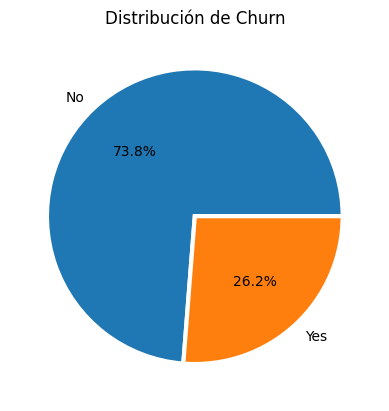

In [81]:
counts = datos['Churn'].value_counts() ##Cuantos clientes hay en cada clase
labels = ['No','Yes']


plt.pie(x = counts, labels=labels, autopct='%1.1f%%', wedgeprops={'edgecolor': 'white', 'linewidth': 3})
plt.title('Distribución de Churn')
plt.show()

El gráfico muestra que la mayoría de los clientes (73.8%) continúa con el servicio, mientras que una menor proporción (26.2%) lo ha cancelado. Esto evidencia un desbalance en las clases, lo que es relevante tener en cuenta en análisis posteriores o al desarrollar modelos predictivos, ya que puede afectar el rendimiento y la interpretación de los resultados.

###3. Recuento de evasión por variables categóricas


A continuación, se analiza cómo se distribuye la evasión (`Churn`) según variables categóricas clave: **género**, **tipo de contrato**, **método de pago**, **tipo de servicio de internet** y **contrato**.

Para cada variable, se calcula la tasa de evasión promedio por categoría y se representa visualmente mediante gráficos de barras, lo que facilita identificar patrones de comportamiento.

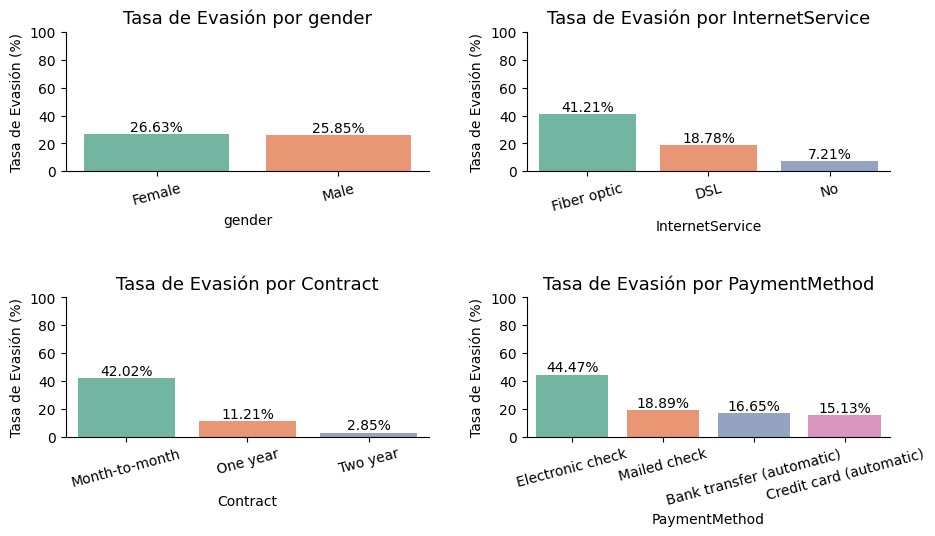

In [117]:
cat_vars = ['gender', 'InternetService', 'Contract', 'PaymentMethod']

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

for idx, var in enumerate(cat_vars):
    churn_rate = datos.groupby(var)['Churn'].mean().reset_index()
    churn_rate.columns = [var, 'Tasa de Evasión']
    churn_rate = churn_rate.sort_values('Tasa de Evasión', ascending=False)
    churn_rate['Tasa de Evasión'] = churn_rate['Tasa de Evasión'] * 100

    sns.barplot(data=churn_rate, x=var, y='Tasa de Evasión',
                palette="Set2", ax=axes[idx])
    axes[idx].set_title(f'Tasa de Evasión por {var}', fontsize=13)
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Tasa de Evasión (%)')
    axes[idx].set_ylim(0, 100)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

    for p in axes[idx].patches:
        axes[idx].annotate(f'{p.get_height():.2f}%',
                           (p.get_x() + p.get_width() / 2., p.get_height()),
                           ha='center', va='bottom', fontsize=10)
    axes[idx].tick_params(axis='x', rotation=15)

plt.tight_layout(pad = 3)
plt.show()

Al analizar la tasa de evasión según variables categóricas, se identificaron
patrones relevantes en el comportamiento de los clientes:

En cuanto al género, la diferencia es mínima: las mujeres presentan una tasa
de evasión del 26.63% y los hombres del 25.85%, por lo que el género no es
un factor determinante en la cancelación del servicio.

Con base al tipo de servicio de internet, los usuarios de Fibra óptica
presentan la mayor tasa de evasión (41.21%), seguidos de DSL (18.78%),
mientras que los clientes sin servicio de internet casi no cancelan (7.21%).

El tipo de contrato es la variable con mayor impacto: los contratos
mes a mes tienen una tasa de evasión del 42.02%, mientras que los
contratos anuales bajan al 11.21% y los bianuales apenas alcanzan
el 2.85%.

Finalmente, el método de pago también influye significativamente.
Los clientes que pagan con cheque electrónico tienen la tasa más
alta (44.47%), mientras que los métodos automáticos (transferencia
bancaria y tarjeta de crédito) presentan tasas menores, alrededor
del 15-17%.

###4. Conteo de evasión por variables numéricas

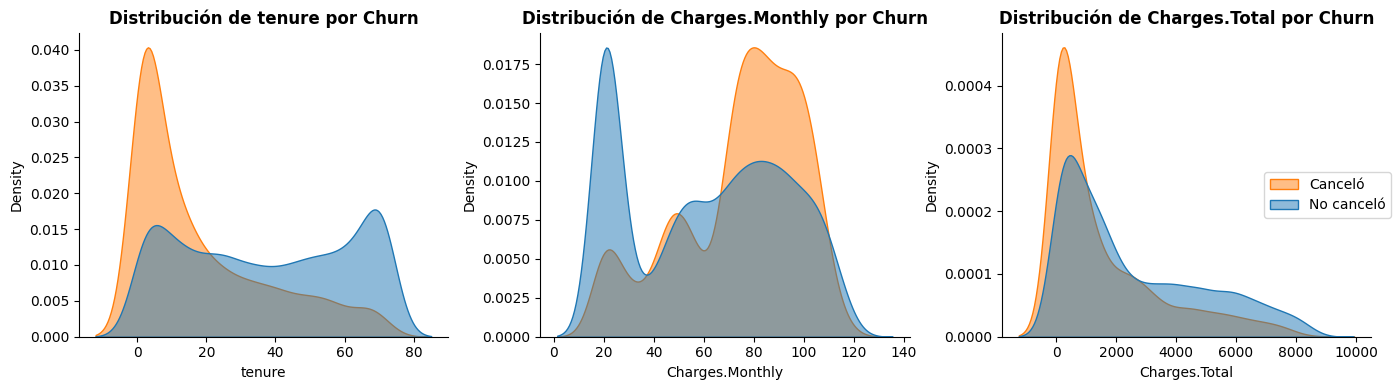

In [159]:

num_vars = ['tenure', 'Charges.Monthly', 'Charges.Total']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for idx, var in enumerate(num_vars):
    sns.kdeplot(data=datos, x=var, hue='Churn',
                fill=True, alpha=0.5, common_norm=False, ax=axes[idx], legend=False)

    axes[idx].set_title(f'Distribución de {var} por Churn',
                        fontweight='bold')
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

fig.legend(labels=['Canceló', 'No canceló'], loc='center right')
plt.tight_layout()
plt.show()


Al analizar la distribución de las variables numéricas entre los clientes
que cancelaron y los que no, se identificaron patrones relevantes:

En cuanto al tiempo de permanencia (tenure), los clientes que cancelaron
se concentran principalmente en los primeros meses de contrato, con un
pico notable entre 1 y 10 meses. En cambio, los clientes que no cancelaron
presentan una distribución más uniforme, con un segundo pico hacia los
70 meses. Esto indica que los clientes nuevos son los más vulnerables
a la cancelación, mientras que los de mayor antigüedad tienden a
permanecer en el servicio.

Respecto al cargo mensual (Charges.Monthly), los clientes que cancelaron
tienden a pagar tarifas más altas, con su pico de densidad entre los
$70 y $100. Por el contrario, los que no cancelaron muestran un pico
importante en tarifas bajas, alrededor de $20. Esto sugiere que los
clientes con cargos elevados tienen mayor propensión a abandonar el
servicio, posiblemente por insatisfacción con la relación precio-valor.

Finalmente, en el cargo total acumulado (Charges.Total), los clientes
que cancelaron concentran sus valores en montos bajos, cercanos a $500,
lo cual es consistente con su corta permanencia. Los clientes que no
cancelaron presentan una distribución más amplia, reflejando un mayor
tiempo de contrato y por ende un mayor gasto acumulado.

#**💡Conclusiones**



A partir del análisis exploratorio realizado sobre los datos de clientes
de Telecom X, se identificaron los siguientes hallazgos principales:

1. La tasa de evasión global es del 26.2%, lo que representa más de 1
   de cada 4 clientes, una proporción significativa que requiere atención
   estratégica inmediata.

2. El tipo de contrato es el factor más determinante: los clientes con
   contrato mes a mes presentan una tasa de evasión del 42.02%, mientras
   que los contratos anuales y bianuales la reducen drásticamente a
   11.21% y 2.85% respectivamente.

3. El servicio de Fibra óptica está fuertemente asociado a la evasión
   (41.21%), muy por encima de DSL (18.78%) y de quienes no tienen
   internet (7.21%). Esto podría indicar insatisfacción con la calidad
   o el precio de este servicio.

4. El método de pago refleja el nivel de compromiso del cliente: quienes
   pagan con cheque electrónico tienen la tasa más alta de evasión
   (44.47%), mientras que los métodos automáticos presentan tasas
   significativamente menores (15-19%).

5. Los clientes nuevos son los más vulnerables: la mayoría de las
   cancelaciones ocurre en los primeros meses de contrato, mientras
   que los clientes con mayor antigüedad raramente cancelan.

6. Los cargos mensuales altos están asociados a mayor evasión,
   sugiriendo sensibilidad al precio especialmente en clientes
   con tarifas entre $70 y $100.

7. El género no es un factor relevante, con tasas de evasión
   prácticamente iguales entre hombres (25.85%) y mujeres (26.63%).

#**🎯 Recomendaciones**


A partir del análisis exploratorio realizado sobre los datos de clientes
de Telecom X, se identificaron los siguientes hallazgos principales:

1. La tasa de evasión global es del 26.2%, lo que representa más de 1
   de cada 4 clientes, una proporción significativa que requiere atención
   estratégica inmediata.

2. El tipo de contrato es el factor más determinante: los clientes con
   contrato mes a mes presentan una tasa de evasión del 42.02%, mientras
   que los contratos anuales y bianuales la reducen drásticamente a
   11.21% y 2.85% respectivamente.

3. El servicio de Fibra óptica está fuertemente asociado a la evasión
   (41.21%), muy por encima de DSL (18.78%) y de quienes no tienen
   internet (7.21%). Esto podría indicar insatisfacción con la calidad
   o el precio de este servicio.

4. El método de pago refleja el nivel de compromiso del cliente: quienes pagan con cheque electrónico tienen la tasa más alta de evasión (44.47%), mientras que los métodos automáticos presentan tasas significativamente menores (15-19%).

5. Los clientes nuevos son los más vulnerables: la mayoría de las
   cancelaciones ocurre en los primeros meses de contrato, mientras
   que los clientes con mayor antigüedad raramente cancelan.

6. Los cargos mensuales altos están asociados a mayor evasión,
   sugiriendo sensibilidad al precio especialmente en clientes
   con tarifas entre $70  y
    $100.

7. El género no es un factor relevante, con tasas de evasión
   prácticamente iguales entre hombres (25.85%) y mujeres (26.63%).